# Assurance — exploration, modèle et vérification

Notebook exécuté de restitution du test. Les métriques affichées ont été calculées par `python -m partie1_ml.train`, qui exécute le split, la CV, l'évaluation, SHAP et la sérialisation. Ce notebook contrôle les artefacts et ne réentraîne pas implicitement sur le holdout. Assistance : ChatGPT ; relecture personnelle du candidat encore nécessaire.

In [1]:
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import joblib
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if not (ROOT / 'partie1_ml').exists():
    ROOT = ROOT.parent
assert (ROOT / 'partie1_ml/model.joblib').exists()
def read_json(path):
    return json.loads((ROOT / path).read_text(encoding='utf-8'))
df = pd.read_csv(ROOT / 'data/dataset_assurance_churn.csv')
audit = read_json('partie1_ml/outputs/dataset_audit.json')
meta = read_json('partie1_ml/metadata.json')
metrics = read_json('partie1_ml/outputs/metrics.json')
print({'clients': len(df), 'colonnes': len(df.columns), 'churn': float(df.churned.mean())})
assert hashlib.sha256((ROOT / 'data/dataset_assurance_churn.csv').read_bytes()).hexdigest() == meta['dataset_sha256']

{'clients': 2000, 'colonnes': 20, 'churn': 0.246}


## 1. Qualité et split avant les choix statistiques

Le CSV original est conservé. Identifiants uniques, cible binaire, contrôles de domaine ; la date d'observation reste absente. L'EDA utilisée pour les décisions porte sur le train.

In [2]:
display(pd.DataFrame({'valeurs_manquantes': df.isna().sum(), 'type': df.dtypes.astype(str)}))
split = read_json('partie1_ml/outputs/split_manifest.json')
assert set(split['train_client_ids']).isdisjoint(split['test_client_ids'])
train = df.set_index('client_id').loc[split['train_client_ids']].reset_index()
test = df.set_index('client_id').loc[split['test_client_ids']].reset_index()
print('Train / test :', len(train), len(test))
display(train.describe().round(3))

,valeurs_manquantes,type
client_id,0,object
age,0,int64
situation_familiale,0,object
profession,0,object
region,0,object
anciennete_mois,0,int64
produit_principal,0,object
niveau_couverture,0,object
canal_souscription,0,object
prime_mensuelle_eur,0,float64


Train / test : 1600 400


,age,anciennete_mois,prime_mensuelle_eur,nb_sinistres_12m,montant_sinistres_eur,nb_appels_support_12m,nb_avenants_contrat,retard_paiement_nb,score_satisfaction,resiliation_anterieure,churned
count,1600.000,1600.000,1600.000,1600.000,1600.000,1534.000,1600.000,1600.000,1536.000,1600.000,1600.000
mean,47.803,90.195,152.184,0.736,1316.223,1.178,1.494,0.443,3.762,0.178,0.246
std,15.393,49.043,98.827,1.014,2744.917,1.303,1.122,0.802,1.087,0.382,0.431
min,22.000,12.000,38.280,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
25%,34.000,48.000,79.675,0.000,0.000,0.000,0.000,0.000,3.000,0.000,0.000
50%,47.000,96.000,119.030,0.000,0.000,1.000,1.000,0.000,4.000,0.000,0.000
75%,61.250,132.000,203.722,1.000,1877.332,2.000,2.250,1.000,5.000,0.000,0.000
max,74.000,168.000,479.830,4.000,39404.530,5.000,3.000,3.000,5.000,1.000,1.000


### Extrêmes et valeurs manquantes

Les sinistres élevés sont conservés ; log1p atténue la queue. L'imputation médiane avec indicateurs de manque est apprise dans chaque fold, jamais sur tout le fichier. Ni ancienneté reconstruite ni récence fondée sur la date actuelle.

{'n_train': 1600,
 'churn_rate_train': 0.24625,
 'sinistres_iqr_upper_train': 4693.331249999999,
 'sinistres_above_iqr_train': 120,
 'sinistres_max_train': 39404.53,
 'treatment': 'Aucune suppression ni winsorisation : log1p du montant dans la pipeline.',
 'missing_train': {'client_id': 0,
  'age': 0,
  'situation_familiale': 0,
  'profession': 0,
  'region': 0,
  'anciennete_mois': 0,
  'produit_principal': 0,
  'niveau_couverture': 0,
  'canal_souscription': 0,
  'prime_mensuelle_eur': 0,
  'nb_sinistres_12m': 0,
  'montant_sinistres_eur': 0,
  'nb_appels_support_12m': 66,
  'nb_avenants_contrat': 0,
  'retard_paiement_nb': 0,
  'score_satisfaction': 64,
  'resiliation_anterieure': 0,
  'date_souscription': 0,
  'date_derniere_interaction': 0,
  'churned': 0}}

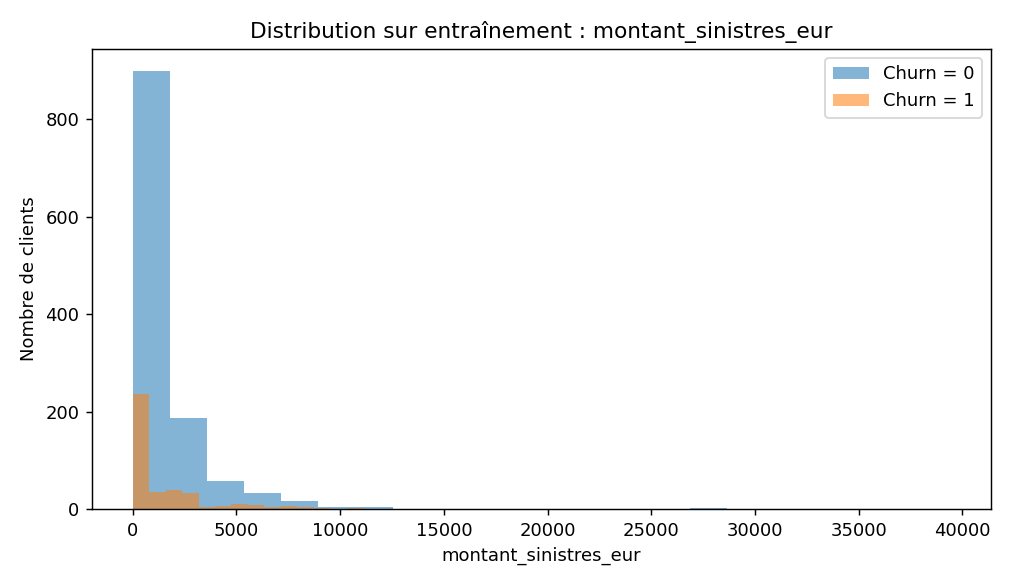

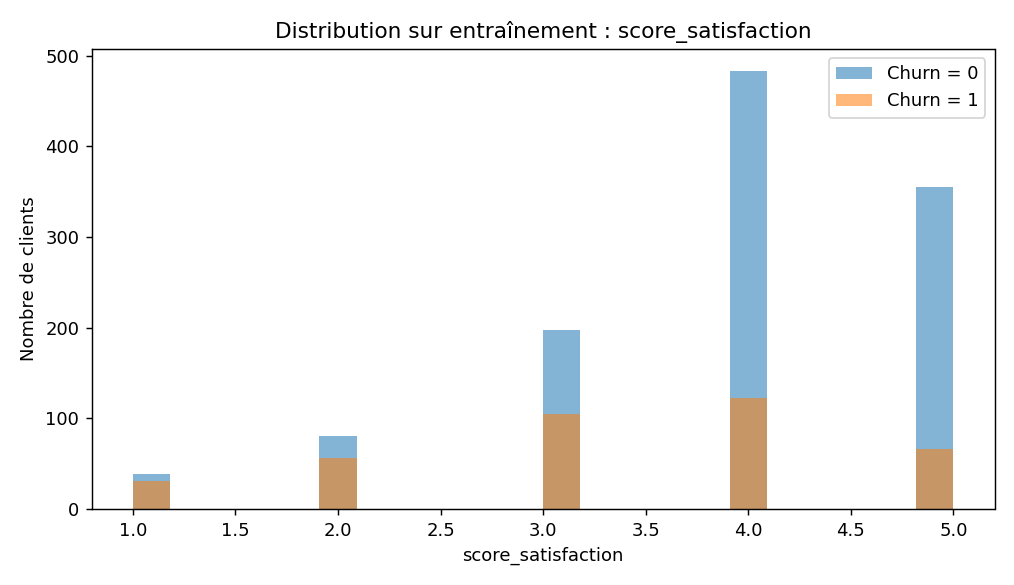

In [3]:
display(read_json('partie1_ml/outputs/eda.json'))
display(Image(filename=str(ROOT / 'docs/figures/distribution_montant_sinistres_eur.png')))
display(Image(filename=str(ROOT / 'docs/figures/distribution_score_satisfaction.png')))

## 2. Trois features métier partagées avec l'API

Appels/(1+sinistres annuels), (5−satisfaction)×appels, retards×résiliation antérieure. Les unités et horizons sont compatibles ; ce sont des signaux associatifs, pas une rentabilité actuarielle. Les dates et l'identifiant ne sont pas des prédicteurs.

In [4]:
model = joblib.load(ROOT / 'partie1_ml/model.joblib')
transformed = model.named_steps['features'].transform(train.drop(columns='churned'))
from partie1_ml.features import DERIVED, NUMERIC
display(transformed[DERIVED].head(8))
assert not {'client_id','churned','date_souscription','date_derniere_interaction'} & set(transformed.columns)
learned = model.named_steps['preprocessor'].named_transformers_['num'].named_steps['imputer'].statistics_
np.testing.assert_allclose(learned, transformed[NUMERIC].median().to_numpy(), rtol=0, atol=0)
print('Médianes du train vérifiées.')

,support_par_sinistre_lisse,tension_relationnelle,retards_x_resiliation,log_montant_sinistres
0,0.000000,0.0,0.0,7.599597
1,0.333333,1.0,0.0,6.527826
2,0.500000,2.0,0.0,7.272058
3,2.000000,0.0,0.0,0.000000
4,1.666667,5.0,0.0,8.640958
5,0.000000,0.0,0.0,0.000000
6,0.000000,0.0,0.0,7.942547
7,3.000000,3.0,0.0,0.000000


Médianes du train vérifiées.


## 3. Validation croisée et test final

Deux modèles pondérés, cinq folds stratifiés, graine 42. Choix sur l'Average Precision de CV. Seuil fixé à 0,5 avant l'expérience. La forêt a un F1 test supérieur, mais le choix n'est pas changé après examen du holdout.

,AP_CV,ecart_type_CV,auc_roc,average_precision,precision,recall,f1,brier,threshold,n,positive_support
modele,,,,,,,,,,,
logistic_regression,0.405,0.0425,0.6994,0.4835,0.3793,0.6735,0.4853,0.2268,0.5,400,98
random_forest,0.378,0.0184,0.6976,0.4475,0.4480,0.5714,0.5022,0.2164,0.5,400,98


Sélection : logistic_regression
Paramètres : {'model__C': 0.03}


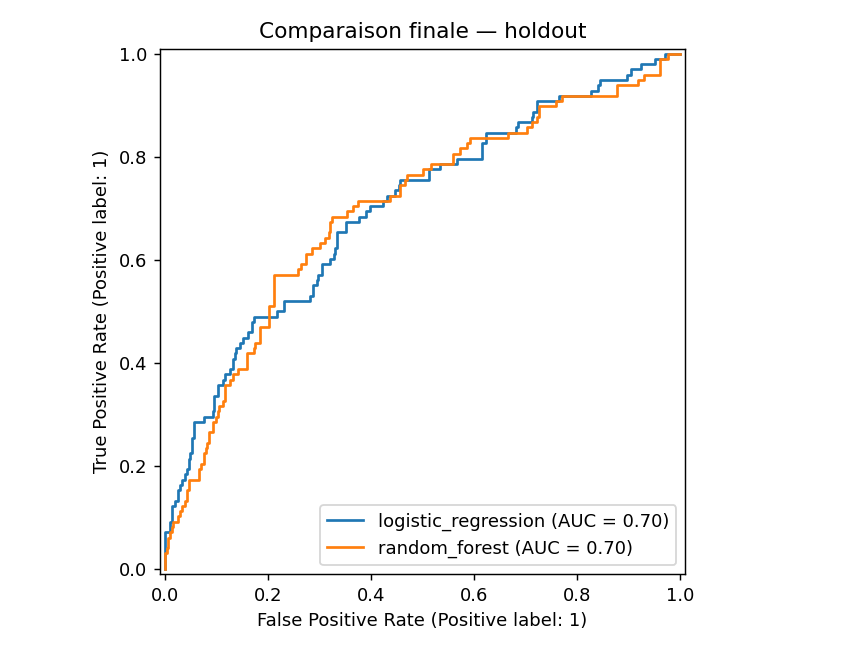

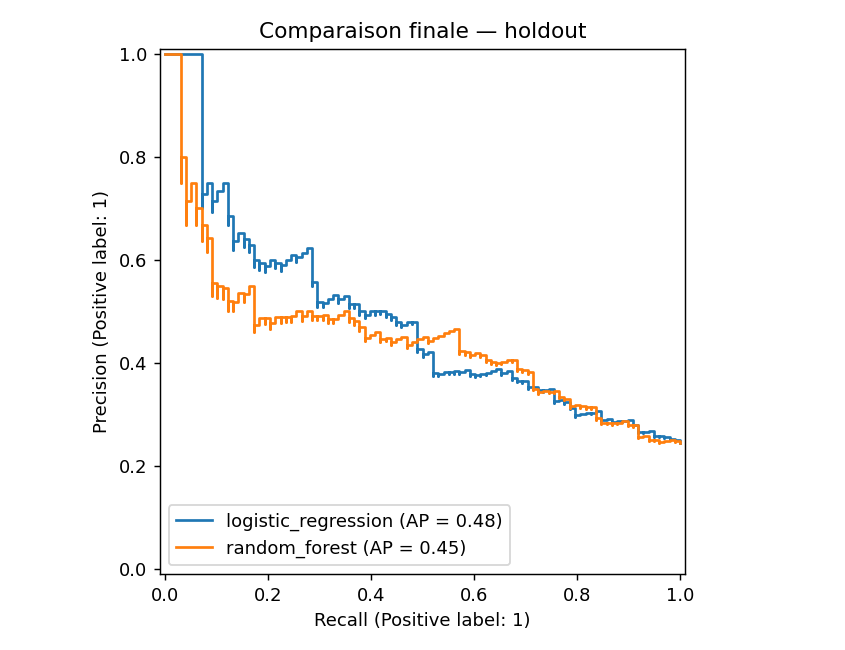

In [5]:
rows = []
for name, item in metrics['candidates'].items():
    rows.append({'modele': name, 'AP_CV': item['cv_ap_mean'], 'ecart_type_CV': item['cv_ap_std'], **{k:v for k,v in item['holdout'].items() if k != 'confusion_matrix'}})
display(pd.DataFrame(rows).set_index('modele').round(4))
print('Sélection :', metrics['selected_model'])
print('Paramètres :', metrics['candidates'][metrics['selected_model']]['best_parameters'])
display(Image(filename=str(ROOT / 'docs/figures/roc.png')))
display(Image(filename=str(ROOT / 'docs/figures/precision_recall.png')))

### Compromis de campagne et calibration

66 churners détectés, 32 manqués, 108 faux positifs, 194 vrais négatifs. Le Brier pondéré est moins bon que la référence constante : les scores ne sont pas des probabilités calibrées. Sans coûts ni effet causal d'une action, aucun ROI n'est calculé.

AUC rechargée : 0.6993850520340587
Intervalle bootstrap percentile, modèle fixé : [0.6397553260291258, 0.7620340717590465]
Brier dummy : 0.18497656249999994


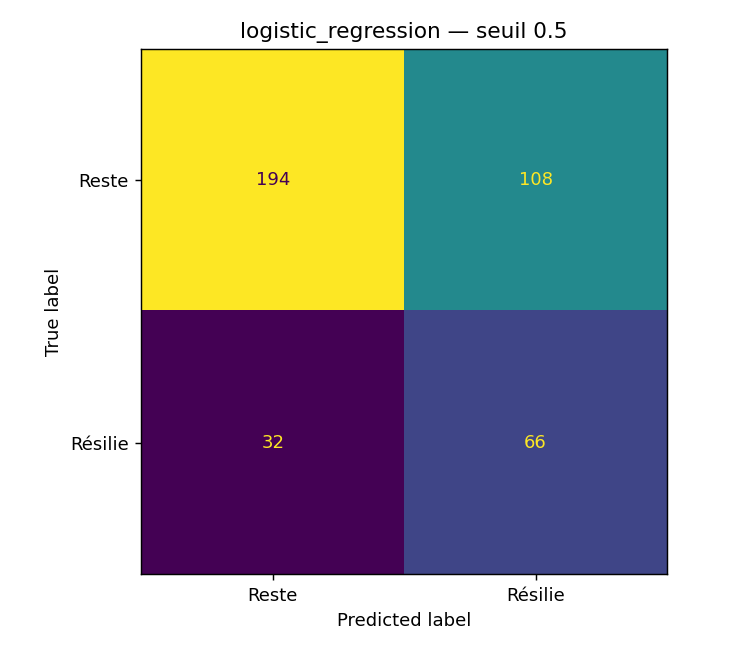

In [6]:
from sklearn.metrics import roc_auc_score, confusion_matrix
p = model.predict_proba(test.drop(columns='churned'))[:,1]
assert abs(roc_auc_score(test.churned, p) - meta['metrics']['auc_roc']) < 1e-12
print('AUC rechargée :', roc_auc_score(test.churned, p))
print('Intervalle bootstrap percentile, modèle fixé :', meta['holdout_auc_bootstrap_95_percentile'])
print('Brier dummy :', metrics['dummy_baseline']['brier'])
display(Image(filename=str(ROOT / 'docs/figures/confusion_matrix.png')))

## 4. SHAP et permutation

SHAP calculé sur 120 lignes du holdout avec 100 lignes de référence train. L'échelle de la régression est le log-odds. L'importance absolue n'indique pas la direction et ne prouve pas de causalité.

,feature,mean_abs_shap
0,num__score_satisfaction,0.294750
1,num__resiliation_anterieure,0.227204
2,num__retard_paiement_nb,0.182403
3,num__nb_sinistres_12m,0.140194
4,num__anciennete_mois,0.137706
5,num__prime_mensuelle_eur,0.117722
6,num__log_montant_sinistres,0.075873
7,num__tension_relationnelle,0.071852
8,cat__situation_familiale_En couple,0.060770
9,num__age,0.053997


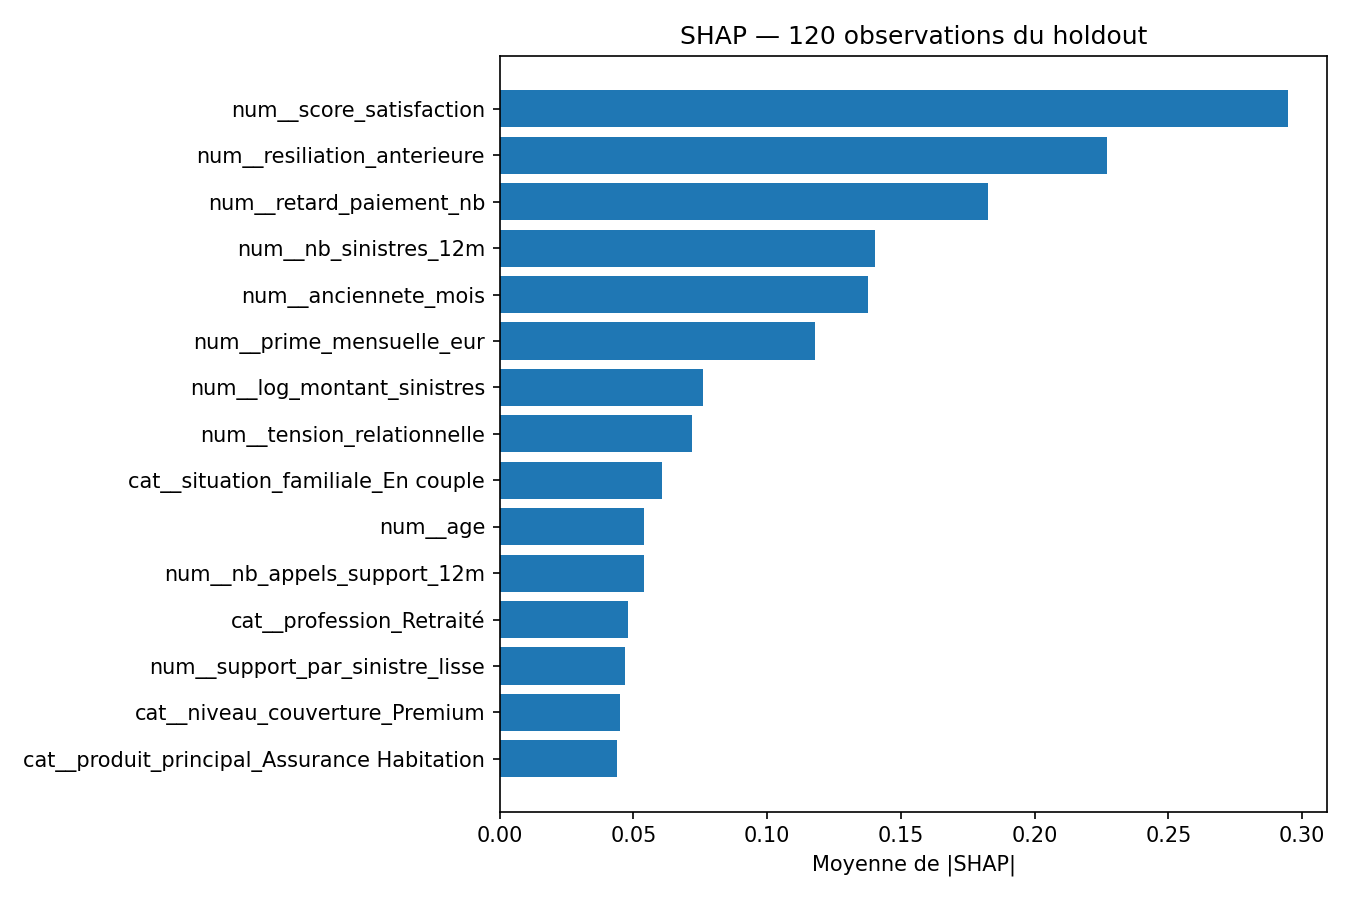

num__score_satisfaction       -0.428569
num__resiliation_anterieure    0.251631
num__retard_paiement_nb        0.260491
num__nb_sinistres_12m          0.170055
num__anciennete_mois          -0.163733
dtype: float64

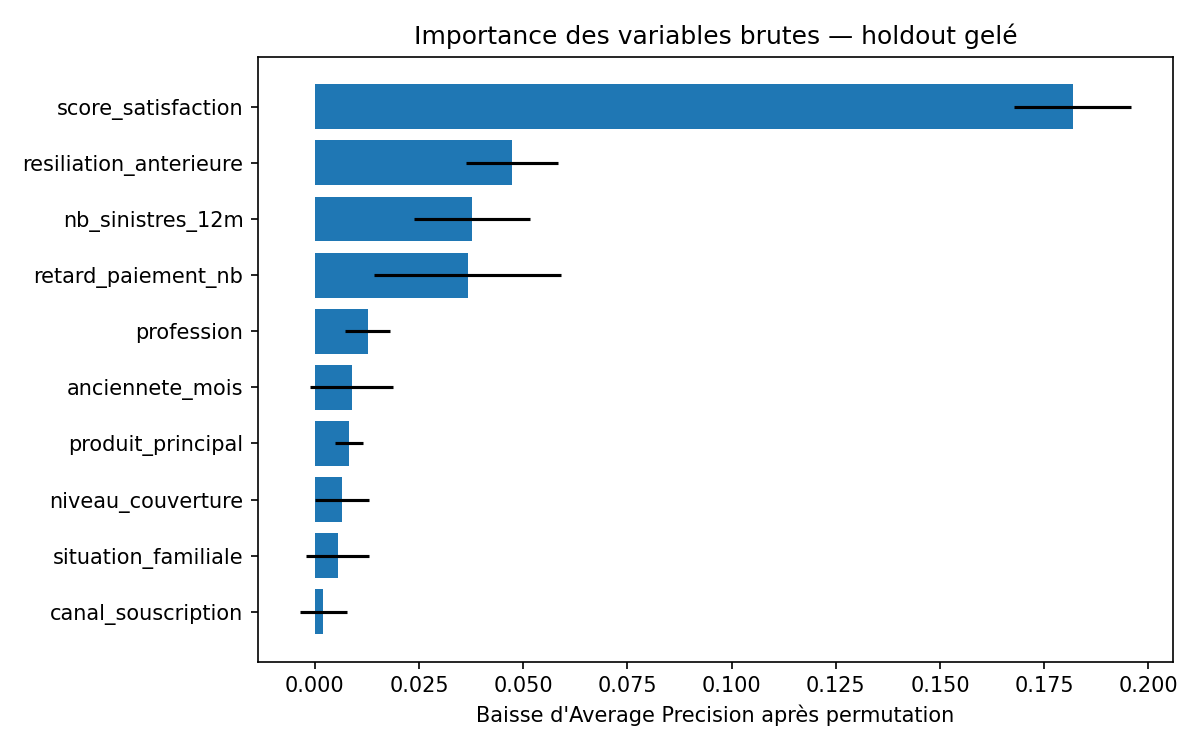

In [7]:
display(pd.read_csv(ROOT / 'partie1_ml/outputs/shap_importance.csv').head(10))
display(Image(filename=str(ROOT / 'docs/figures/shap_importance.png')))
names = model[:-1].get_feature_names_out()
coeff = pd.Series(model.named_steps['model'].coef_[0], index=names)
display(coeff.loc[['num__score_satisfaction','num__resiliation_anterieure','num__retard_paiement_nb','num__nb_sinistres_12m','num__anciennete_mois']])
display(Image(filename=str(ROOT / 'docs/figures/permutation_importance.png')))

## 5. Artefact utilisé par l'API

Le pipeline complet est chargé une fois, avec empreinte et métadonnées. L'exemple ci-dessous est synthétique. Le test HTTP réel est archivé séparément dans docs/evidence/http_smoke.json.

In [8]:
example = read_json('partie3_mlops/example_request.json')
print({'client_id':example['client_id'], 'probability':float(model.predict_proba(pd.DataFrame([example]))[0,1])})
assert hashlib.sha256((ROOT / 'partie1_ml/model.joblib').read_bytes()).hexdigest() == meta['model_sha256']
display(read_json('docs/evidence/http_smoke.json')['health'])

{'client_id': 'DEMO-001', 'probability': 0.4663275906686875}


{'status': 'ok', 'model_version': '1.0.0-cf63ac276d'}

## 6. Résumé RAG, avec sa provenance réelle

L'index LSA/NumPy, le retrieval et les scores sont exécutés. Les réponses jointes sont un lot ChatGPT orchestré manuellement, pas une preuve d'inférence Ollama autonome. La fidélité du lot n'est pas notée comme un benchmark indépendant.

In [9]:
rag = read_json('partie2_rag/results.json')
display(pd.DataFrame([{'question':r['question_id'], 'mode':r['mode'], 'P_at_5':r['metrics']['context_precision'], 'rappel_preuves':r['metrics']['evidence_recall'], 'generation':r['generation']['status']} for r in rag['runs']]))
print('Chunks :', rag['corpus']['n_chunks'])
print('Live API vérifiée :', rag['batch_import']['live_api_verified'])

,question,mode,P_at_5,rappel_preuves,generation
0,Q1,dense,0.0,0.000000,generated_interactive_batch
1,Q1,hybrid,0.0,0.000000,generated_interactive_batch
2,Q1,hybrid_filtered,0.2,0.333333,generated_interactive_batch
3,Q2,dense,0.2,0.500000,generated_interactive_batch
4,Q2,hybrid,0.2,0.500000,generated_interactive_batch
5,Q2,hybrid_filtered,0.4,1.000000,generated_interactive_batch
6,Q3,dense,0.6,0.750000,generated_interactive_batch
7,Q3,hybrid,0.6,0.750000,generated_interactive_batch
8,Q3,hybrid_filtered,0.6,0.750000,generated_interactive_batch
9,Q4,dense,0.4,0.666667,generated_interactive_batch


Chunks : 110
Live API vérifiée : False


## Pour reproduire et poursuivre

`python -m partie1_ml.train` relance les entraînements. `python -m pytest -q` contrôle la suite. `python -m scripts.smoke_docker` et le benchmark `--generation ollama` nécessitent les services correspondants. Les limitations et choix à défendre sont développés dans README.md et docs/DEBRIEF.md.